## Example ENERF scene preparation  

In this notebook we show all steps required to prepare ENeRF scene for training **from scratch**. 

<span style="color:red">
We do not recommend using it unless you really want to test on a new scene that is not provided in our Zenodo dataset. Please see point 6 for a WARNING.
</span>. 

In paper we used two sequences:
- **Actor 1 (timesteps 710 - 780)**  
- **Actor 3 (timesteps 895-950)**

First you need to access the download link from: https://github.com/zju3dv/ENeRF/blob/master/docs/enerf_outdoor.md.  

Once you obtain the link, use ENERF folder for selected actor.  You will need COLMAP installed. This notebook shows steps for Actor1.

## 0. Set paths

In original ENERF data, for Actor1 `images` structure look like this:

```
images/
├── 00/ # camera idx
│   ├── 000000.jpg # timestep idx
│   ├── 000001.jpg
...
├── 17/                  
│   ├── 000000.jpg        
│   ├── 000001.jpg

```

In [ ]:
# === SET PATHS AND TIMESTEPS HERE ===
ACTOR_PATH = "path/to/enerf/actor1"
LUMIMOTION_DATA=f"{ACTOR_PATH}/actor1_710_780"

min_ts = 710
max_ts = 780
# ====================================

## 1. Prepare empty COLMAP DataBase.

[**WARNING**]   

We run colmap reconstruction **on background images first**, and then we reuse colmap model on dynamic images (with actors).  

Running colmap on dynamic images directly (even on a single step) gives inaccurate estimations.

In [ ]:
IMAGE_BG_DIR=f"{ACTOR_PATH}/bkgd"
IMAGE_DIR=f"{ACTOR_PATH}/images"
COLMAP_PATH=f"{ACTOR_PATH}/colmap_bkgd"
DB_PATH=f"{COLMAP_PATH}/database.db"
SPARSE_PATH=f"{COLMAP_PATH}/sparse"

In [ ]:
from colmap_database import COLMAPDatabase
import os

if os.path.exists(DB_PATH):
    os.remove(DB_PATH)

if not os.path.exists(COLMAP_PATH):
    os.makedirs(COLMAP_PATH)

db = COLMAPDatabase.connect(DB_PATH)
db.create_tables()

db.commit()
db.close()

print(f"✅ Created database at: {DB_PATH}")


## 2. Reconstruct background photos with default COLMAP settings. Undistort them.

In [ ]:
!colmap feature_extractor \
    --database_path $DB_PATH \
    --image_path $IMAGE_BG_DIR

In [ ]:
!colmap exhaustive_matcher \
    --database_path $DB_PATH

In [ ]:
!mkdir -p $SPARSE_PATH

!colmap mapper \
    --database_path $DB_PATH \
    --image_path $IMAGE_BG_DIR \
    --output_path $SPARSE_PATH


In [ ]:
UNDISTORTED_PATH = f"{COLMAP_PATH}/undistorted"
os.makedirs(UNDISTORTED_PATH, exist_ok=True)

!colmap image_undistorter \
    --image_path $IMAGE_BG_DIR \
    --input_path $SPARSE_PATH/0 \
    --output_path $UNDISTORTED_PATH \
    --output_type COLMAP

## 3. We train LumiMotion only on a short sequence, subset of timesteps. 
Snippet below copies dynamic images for selected timesteps (for example 710-780). The output folder `images_710_780` will be structured as:

```
images_710_780/
├── 0000710/          # timestep idx
│   ├── 00.jpg        # camera idx
│   ├── 01.jpg
│   ├── ...
│   └── 17.jpg
└── ...
│
├── 0000780/
│   ├── 00.jpg
│   ├── 01.jpg
│   ├── ...
│   └── 17.jpg

```

In [ ]:
import shutil
import re

source_root = IMAGE_DIR
dest_root = f"{LUMIMOTION_DATA}/images_{min_ts}_{max_ts}"
os.makedirs(dest_root, exist_ok=True)

# === Go through each camera directory
for cam_id in sorted(os.listdir(source_root)):
    cam_path = os.path.join(source_root, cam_id)
    if not os.path.isdir(cam_path):
        continue

    for filename in sorted(os.listdir(cam_path)):
        if not filename.lower().endswith(".jpg"):
            continue

        # Extract numeric timestamp from filename
        match = re.search(r"\d{6}", filename)
        if not match:
            continue
        ts = int(match.group())

        # Check timestamp range
        if min_ts <= ts <= max_ts:
            # Create target directory and copy file
            target_dir = os.path.join(dest_root, f"{ts:06d}")
            os.makedirs(target_dir, exist_ok=True)

            src_file = os.path.join(cam_path, filename)
            dst_file = os.path.join(target_dir, f"{cam_id}.jpg")

            shutil.copyfile(src_file, dst_file)


## 4. Undistort copied dynamic images with COLMAP undistortion model obtained for background.
The output folder: `actor1_710_780/images_710_780_undistorted`

In [ ]:
import subprocess

# Paths
IMAGES_COPIED_UNDISTORTED_PATH = f"{dest_root}_undistorted"
os.makedirs(IMAGES_COPIED_UNDISTORTED_PATH, exist_ok=True)

folders = sorted([f for f in os.listdir(dest_root) if os.path.isdir(os.path.join(dest_root, f))])

for folder in folders:
    image_path = os.path.join(dest_root, folder)
    output_path = os.path.join(IMAGES_COPIED_UNDISTORTED_PATH, folder)
    os.makedirs(output_path, exist_ok=True)

    print(f"[INFO] Undistorting: {folder}")

    subprocess.run([
        "colmap", "image_undistorter",
        "--image_path", image_path,
        "--input_path", f"{SPARSE_PATH}/0", # sparse path has colmap model for background
        "--output_path", output_path,
        "--output_type", "COLMAP"
    ], check=True)

    # === Cleanup: Remove 'sparse' and 'stereo' folders ===
    sparse_dir = os.path.join(output_path, "sparse")
    stereo_dir = os.path.join(output_path, "stereo")

    if os.path.exists(sparse_dir):
        shutil.rmtree(sparse_dir)
        print(f"🧹 Removed: {sparse_dir}")

    if os.path.exists(stereo_dir):
        shutil.rmtree(stereo_dir)
        print(f"🧹 Removed: {stereo_dir}")



## 5. To generate 3D point cloud (background + actor), we need COLMAP reconstruction for one timestep.

Get one timestep (for example 730). Reuse COLMAP model we obtained for static background, also do undistortion.   
Colmap generates sparse 3d point cloud for this timestep.   
The output folder: `actor1_710_780/colmap_000730_undistorted`

In [ ]:
# === SET ONE TIMESTEP HERE ===
timestep_num = 730
#==============================


timestep_num=str(timestep_num).zfill(6)
NEW_IMAGE_DIR = f"{dest_root}/{timestep_num}"

# this is COLMAP_PATH colmap model for static background 
SPARSE_BIN = f"{COLMAP_PATH}/sparse/0"
SPARSE_TXT = f"{COLMAP_PATH}/sparse_txt"
SPARSE_NEW = f"{LUMIMOTION_DATA}/colmap_{timestep_num}"

os.makedirs(SPARSE_TXT, exist_ok=True)
os.makedirs(SPARSE_NEW, exist_ok=True)

NEW_DB_PATH = f"{SPARSE_NEW}/database.db"

if os.path.exists(NEW_DB_PATH):
    os.remove(NEW_DB_PATH)


# Create fresh COLMAP database with required tables
db = COLMAPDatabase.connect(NEW_DB_PATH)
db.create_tables()
db.commit()
db.close()


In [ ]:
!colmap model_converter \
    --input_path "{SPARSE_BIN}" \
    --output_path "{SPARSE_TXT}" \
    --output_type TXT


In [ ]:
!colmap feature_extractor \
    --database_path "{NEW_DB_PATH}" \
    --image_path "{NEW_IMAGE_DIR}"


In [ ]:
!colmap exhaustive_matcher --database_path $NEW_DB_PATH

In [ ]:
!colmap point_triangulator \
    --database_path "{NEW_DB_PATH}" \
    --image_path "{NEW_IMAGE_DIR}" \
    --input_path "{SPARSE_TXT}" \
    --output_path "{SPARSE_NEW}"


In [ ]:
NEW_UNDISTORTED_PATH = f"{SPARSE_NEW}_undistorted"
os.makedirs(NEW_UNDISTORTED_PATH, exist_ok=True)

!colmap image_undistorter \
    --image_path $NEW_IMAGE_DIR \
    --input_path $SPARSE_NEW \
    --output_path $NEW_UNDISTORTED_PATH \
    --output_type COLMAP

In [ ]:
# we do not need distorted folders images_710_780, colmap_000730
!rm -r "$SPARSE_NEW" 
!rm -r "$dest_root" 

## 6. Read generated points3D.bin and save as point cloud (`merged_pcd.ply`).

In [ ]:
import struct
import numpy as np
import open3d as o3d

def read_next_bytes(fid, num_bytes, format_char_sequence, endian_character="<"):
    data = fid.read(num_bytes)
    return struct.unpack(endian_character + format_char_sequence, data)

def read_points3D_binary(path_to_model_file):
    """Read COLMAP points3D.bin"""
    with open(path_to_model_file, "rb") as fid:
        num_points = read_next_bytes(fid, 8, "Q")[0]

        xyzs = np.empty((num_points, 3), dtype=np.float64)
        rgbs = np.empty((num_points, 3), dtype=np.uint8)
        errors = np.empty((num_points,), dtype=np.float64)

        for p_id in range(num_points):
            data = read_next_bytes(fid, 43, "QdddBBBd")
            track_len = read_next_bytes(fid, 8, "Q")[0]
            _ = fid.read(8 * track_len)  # skip track elements

            xyzs[p_id] = data[1:4]
            rgbs[p_id] = data[4:7]
            errors[p_id] = data[7]

    return xyzs, rgbs, errors

def save_to_ply(filename, xyzs, rgbs):
    """Save to PLY file"""
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(xyzs)
    pcd.colors = o3d.utility.Vector3dVector(rgbs.astype(np.float64) / 255.0)
    o3d.io.write_point_cloud(filename, pcd)

# ------------------------
# Main Processing Section
# ------------------------

# List of COLMAP .bin point clouds
bin_paths = [
    f"{SPARSE_NEW}_undistorted/sparse/points3D.bin",
]

all_xyzs, all_rgbs = [], []

for path in bin_paths:
    xyzs, rgbs, _ = read_points3D_binary(path)
    all_xyzs.append(xyzs)
    all_rgbs.append(rgbs)

# Merge all downsampled clouds
merged_xyzs = np.vstack(all_xyzs)
merged_rgbs = np.vstack(all_rgbs)

# Save final merged result
save_to_ply(os.path.join(LUMIMOTION_DATA,"merged_pcd.ply"), merged_xyzs, merged_rgbs)
print(f"✅ Merged point cloud saved to: merged_pcd.ply. Number of vertices: {len(merged_xyzs)}")


<span style="color:red">

## [**WARNING**] Colmap generates very sparse points on Actor! 
If the actor is too transparent in reconstruction, the shadow in reconstruction cannot be cast and consequently removed from albedo! Moreover, inaccurate initialization do not always converge to satisfactory geometry for such a difficult scene as ENERF. 

</span>

Therefore we experimented with densification of point cloud obtained directly from COLMAP. Finally, in Blender we combined:
- points3D from COLMAP from 2 or 3 timesteps,
- added points from Gaussian Splatting pre-training on single timestep,
- then **duplicated manually** actor-points, placing them with slight offset from original positions. 

Final init ply needs to be saved as: `actor1_710_780/merged_pcd.ply`


<span style="color:red">

### PLEASE NOTE: this was a very difficult step and the LumiMotion framework is sensitive to accurate camera poses and proper initialization, especially for quite big real world scenes. Therefore, we provide COLMAP models and point clouds that work well on our ENERF scenes and we encourage to use them. Any better initialization technique is welcome to be proposed in issues.

</span>



## 7. Masks to limit wall area
We noticed that training with extensive wall parts deteriorate the model's ability to proper material estimation in Stage2. We prepared 3D consistent masks to limit scene extend, and we provide the masks we used for Actor1 and Actor3 on our Zenodo repository. Put masks into data folder.

The example masks look like this:

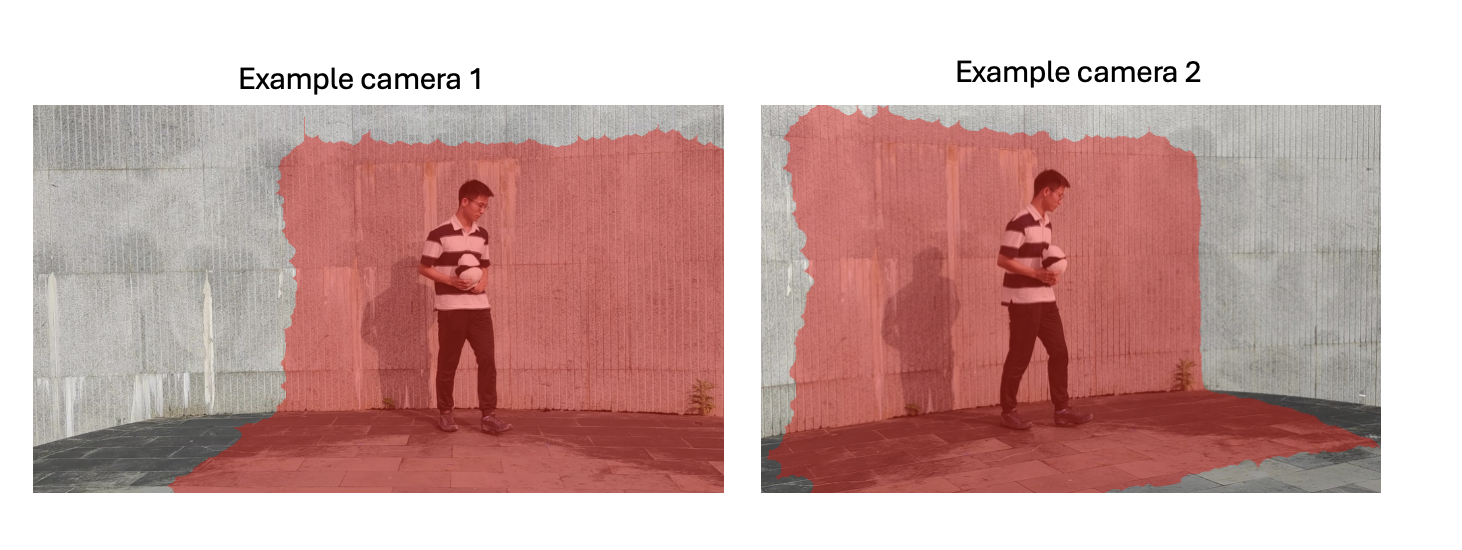

## Notes on Stage2 optimization with masks. 
Please note, that provided scene masks are still quite large - large parts of wall will optimized in Stage2, which may deteriorate material estimation. 
To better focus on shadowed parts, after Stage1 you can remove some wall-gaussians (from areas with no shadow) from `point_cloud/iteration_35000/point_cloud.ply` in SuperSplat and replace the .ply file. We did it for the figures in our paper.

## 8. Final dataset structure:
```
enerf_data
└── actor1_710_780/
    ├── colmap_000730_undistorted/
    ├── images_710_780_undistorted/
    ├── masks_710_780_undistorted/
    └── merged_pcd.ply
```